In [13]:
"""LSTM Volatility Prediction with Monte Carlo Stress Testing
Following methodology from Yachou et al. (2026) and Fischer & Krauss (2018)

Author: Bidisa Biswas
Thesis: Stress Testing Automated Trading Systems
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Add path for data loader
sys.path.append(os.path.abspath('..'))
from src.data_loader import SP500DataLoader

print("="*70)
print("LSTM VOLATILITY PREDICTION WITH MONTE CARLO STRESS TESTING")
print("="*70)

LSTM VOLATILITY PREDICTION WITH MONTE CARLO STRESS TESTING


In [14]:
print("\n" + "="*60)
print("PART 1: DATA LOADING AND PREPARATION")
print("="*60)

# Load S&P 500 data
loader = SP500DataLoader(start_year=1997, end_year=2024)
df = loader.load_all()

# Extract log returns
all_returns = df['log_returns'].dropna()

# Use pre-COVID period for training (2010-2019)
train_returns = all_returns['2010':'2019'].values

print(f"Training data shape: {train_returns.shape}")
print(f"Date range: 2010-01-01 to 2019-12-31")





PART 1: DATA LOADING AND PREPARATION
Training data shape: (2516,)
Date range: 2010-01-01 to 2019-12-31


In [15]:
def create_volatility_sequences(data, lookback=60, vol_window=20):
    """
    Create sequences and volatility labels.
    Following Yachou et al. (2026): 60-day lookback window
    
    Label: 1 if next day's volatility > recent average volatility
    """
    X, y = [], []
    
    for i in range(lookback, len(data) - 1):
        # Input: last 'lookback' returns
        X.append(data[i-lookback:i])
        
        # Calculate recent average volatility (last 'vol_window' days)
        recent_vol = np.abs(data[i-vol_window:i]).mean()
        
        # Next day volatility
        next_vol = np.abs(data[i+1])
        
        # Label: 1 if next volatility > recent average, else 0
        y.append(1 if next_vol > recent_vol else 0)
    
    return np.array(X), np.array(y)

lookback = 60
vol_window = 20

X, y = create_volatility_sequences(train_returns, lookback, vol_window)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: HIGH volatility={y.sum()}, LOW volatility={len(y)-y.sum()}")
print(f"Proportion HIGH: {y.sum()/len(y)*100:.1f}%")


X shape: (2455, 60)
y shape: (2455,)
Class balance: HIGH volatility=992, LOW volatility=1463
Proportion HIGH: 40.4%


In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Scale features (critical for LSTM convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, lookback)).reshape(-1, lookback, 1)
X_val_scaled = scaler.transform(X_val.reshape(-1, lookback)).reshape(-1, lookback, 1)

print(f"\nTrain shape: {X_train_scaled.shape}")
print(f"Validation shape: {X_val_scaled.shape}")



Train shape: (1964, 60, 1)
Validation shape: (491, 60, 1)


In [18]:
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {cls: weight for cls, weight in zip(classes, class_weights)}

print(f"\nClass distribution: LOW={np.sum(y_train==0)}, HIGH={np.sum(y_train==1)}")
print(f"Class weights: {class_weight_dict}")



Class distribution: LOW=1177, HIGH=787
Class weights: {0: 0.8343245539507221, 1: 1.2477763659466328}


In [26]:
def build_volatility_lstm(lookback=60, lstm_units=32, dropout_rate=0.2):
    """
    Build LSTM model for volatility prediction.
    Architecture inspired by Yachou et al. (2026)
    """
    model = Sequential([
        LSTM(lstm_units, return_sequences=False, input_shape=(lookback, 1)),  # ← FIXED
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_volatility_lstm(lookback=lookback, lstm_units=32, dropout_rate=0.2)
model.summary()
print("✅ Model built following Yachou et al. (2026) methodology")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

✅ Model built following Yachou et al. (2026) methodology


In [27]:
# Callbacks for dynamic training (Yachou et al., 2026)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print("\n" + "="*60)
print("PART 6: TRAINING THE MODEL")
print("="*60)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Training complete!")



PART 6: TRAINING THE MODEL
Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.5830 - loss: 0.6801 - val_accuracy: 0.6354 - val_loss: 0.6690 - learning_rate: 0.0010
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6069 - loss: 0.6695 - val_accuracy: 0.6354 - val_loss: 0.6548 - learning_rate: 0.0010
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6044 - loss: 0.6634 - val_accuracy: 0.6171 - val_loss: 0.6475 - learning_rate: 0.0010
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5947 - loss: 0.6637 - val_accuracy: 0.6395 - val_loss: 0.6395 - learning_rate: 0.0010
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5983 - loss: 0.6606 - val_accuracy: 0.6334 - val_loss: 0.6390 - learning_rate: 0.0010
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6013 - loss: 0.6590 - val_accuracy: 0.6415 - val_loss: 0.6377 - learning_rate: 0.0010
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accura

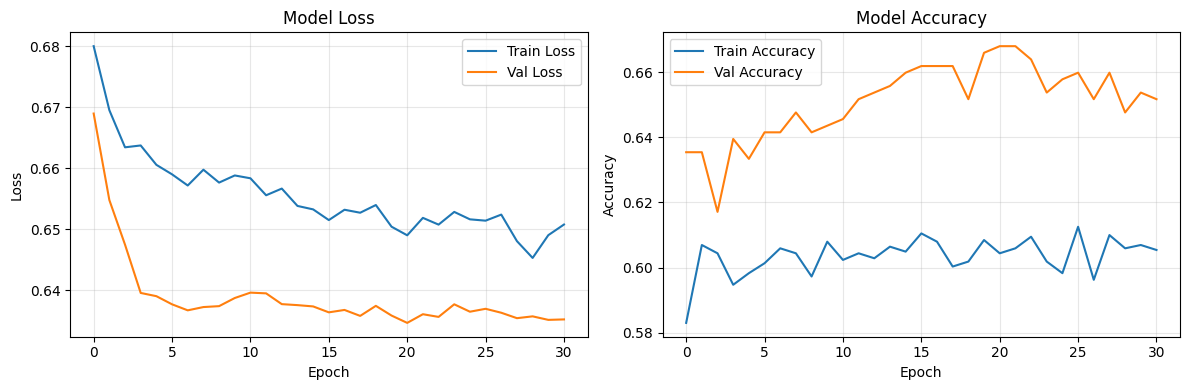

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/lstm_training_history.png', dpi=150)
plt.show()

In [29]:
val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.2%}")



Validation Loss: 0.6346
Validation Accuracy: 66.80%


In [30]:
print("\n" + "="*60)
print("PART 9: LOADING MONTE CARLO PATHS")
print("="*60)

data_path = '../data/simulated/'

normal_paths = np.load(os.path.join(data_path, 'mc_returns_normal.npy'))
crisis_2008_paths = np.load(os.path.join(data_path, 'mc_returns_crisis_2008.npy'))
crisis_covid_paths = np.load(os.path.join(data_path, 'mc_returns_crisis_covid.npy'))
synthetic_paths = np.load(os.path.join(data_path, 'mc_returns_synthetic_extreme.npy'))
squeeze_paths = np.load(os.path.join(data_path, 'mc_returns_squeeze.npy'))
structural_break_paths = np.load(os.path.join(data_path, 'mc_returns_structural_break.npy'))

print(f"Normal paths: {normal_paths.shape}")
print(f"2008 Crisis: {crisis_2008_paths.shape}")
print(f"COVID Crisis: {crisis_covid_paths.shape}")
print(f"Synthetic Extreme: {synthetic_paths.shape}")
print(f"Non-linear Squeeze: {squeeze_paths.shape}")
print(f"Structural Break: {structural_break_paths.shape}")


PART 9: LOADING MONTE CARLO PATHS
Normal paths: (10000, 252)
2008 Crisis: (10000, 252)
COVID Crisis: (10000, 252)
Synthetic Extreme: (10000, 252)
Non-linear Squeeze: (10000, 252)
Structural Break: (10000, 252)


In [31]:
# Combine all paths for fitting the scaler
all_mc_paths = np.vstack([
    normal_paths, crisis_2008_paths, crisis_covid_paths, 
    synthetic_paths, squeeze_paths, structural_break_paths
])

scaler_mc = StandardScaler()
scaler_mc.fit(all_mc_paths[:, -lookback:])

print(f"\n✅ Scaler fitted on {all_mc_paths.shape[0]} Monte Carlo paths")



✅ Scaler fitted on 60000 Monte Carlo paths


In [32]:
def get_volatility_labels_mc(paths, lookback=60, vol_window=20):
    """Get true volatility labels for Monte Carlo paths."""
    n_paths = paths.shape[0]
    labels = []
    for i in range(n_paths):
        path = paths[i]
        recent_vol = np.abs(path[-vol_window:-1]).mean()
        next_vol = np.abs(path[-1])
        labels.append(1 if next_vol > recent_vol else 0)
    return np.array(labels)

def predict_on_paths(model, scaler, paths, lookback=60, batch_size=500):
    """Predict volatility regime on Monte Carlo paths."""
    n_paths = paths.shape[0]
    all_probs = []
    
    for i in range(0, n_paths, batch_size):
        batch = paths[i:i+batch_size]
        features = batch[:, -lookback:]
        features_scaled = scaler.transform(features)
        features_scaled = features_scaled.reshape(-1, lookback, 1)
        probs = model.predict(features_scaled, verbose=0)
        all_probs.extend(probs.flatten())
        
        if (i + batch_size) % 2000 == 0 or i == 0:
            print(f"   Processed: {min(i+batch_size, n_paths)}/{n_paths}")
    
    return np.array(all_probs)

def calculate_accuracy(predictions, true_labels):
    """Calculate directional accuracy."""
    pred_labels = (predictions > 0.5).astype(int)
    return (pred_labels == true_labels).mean() * 100

In [34]:
print("\n" + "="*60)
print("PART 12: STRESS TESTING ON MONTE CARLO PATHS")
print("="*60)

results = {}

# 1. Normal Scenario
print("\n1. Normal scenario...")
true_labels_normal = get_volatility_labels_mc(normal_paths)
probs_normal = predict_on_paths(model, scaler_mc, normal_paths)
acc_normal = calculate_accuracy(probs_normal, true_labels_normal)
results['Normal'] = acc_normal
print(f"   ✅ Accuracy: {acc_normal:.2f}%")

# 2. 2008 Crisis
print("\n2. 2008 Crisis scenario...")
true_labels_2008 = get_volatility_labels_mc(crisis_2008_paths)
probs_2008 = predict_on_paths(model, scaler_mc, crisis_2008_paths)
acc_2008 = calculate_accuracy(probs_2008, true_labels_2008)
results['2008 Crisis'] = acc_2008
print(f"   ✅ Accuracy: {acc_2008:.2f}%")

# 3. COVID Crisis
print("\n3. COVID Crisis scenario...")
true_labels_covid = get_volatility_labels_mc(crisis_covid_paths)
probs_covid = predict_on_paths(model, scaler_mc, crisis_covid_paths)
acc_covid = calculate_accuracy(probs_covid, true_labels_covid)
results['COVID Crisis'] = acc_covid
print(f"   ✅ Accuracy: {acc_covid:.2f}%")

# 4. Synthetic Extreme
print("\n4. Synthetic Extreme scenario...")
true_labels_synthetic = get_volatility_labels_mc(synthetic_paths)
probs_synthetic = predict_on_paths(model, scaler_mc, synthetic_paths)
acc_synthetic = calculate_accuracy(probs_synthetic, true_labels_synthetic)
results['Synthetic Extreme'] = acc_synthetic
print(f"   ✅ Accuracy: {acc_synthetic:.2f}%")

# 5. Non-linear Squeeze
print("\n5. Non-linear Squeeze scenario...")
true_labels_squeeze = get_volatility_labels_mc(squeeze_paths)
probs_squeeze = predict_on_paths(model, scaler_mc, squeeze_paths)
acc_squeeze = calculate_accuracy(probs_squeeze, true_labels_squeeze)
results['Non-linear Squeeze'] = acc_squeeze
print(f"   ✅ Accuracy: {acc_squeeze:.2f}%")

# 6. Structural Break
print("\n6. Structural Break scenario...")
true_labels_break = get_volatility_labels_mc(structural_break_paths)
probs_break = predict_on_paths(model, scaler_mc, structural_break_paths)
acc_break = calculate_accuracy(probs_break, true_labels_break)
results['Structural Break'] = acc_break
print(f"   ✅ Accuracy: {acc_break:.2f}%")


PART 12: STRESS TESTING ON MONTE CARLO PATHS

1. Normal scenario...
   Processed: 500/10000
   Processed: 2000/10000
   Processed: 4000/10000
   Processed: 6000/10000
   Processed: 8000/10000
   Processed: 10000/10000
   ✅ Accuracy: 50.73%

2. 2008 Crisis scenario...
   Processed: 500/10000
   Processed: 2000/10000
   Processed: 4000/10000
   Processed: 6000/10000
   Processed: 8000/10000
   Processed: 10000/10000
   ✅ Accuracy: 52.60%

3. COVID Crisis scenario...
   Processed: 500/10000
   Processed: 2000/10000
   Processed: 4000/10000
   Processed: 6000/10000
   Processed: 8000/10000
   Processed: 10000/10000
   ✅ Accuracy: 51.83%

4. Synthetic Extreme scenario...
   Processed: 500/10000
   Processed: 2000/10000
   Processed: 4000/10000
   Processed: 6000/10000
   Processed: 8000/10000
   Processed: 10000/10000
   ✅ Accuracy: 52.89%

5. Non-linear Squeeze scenario...
   Processed: 500/10000
   Processed: 2000/10000
   Processed: 4000/10000
   Processed: 6000/10000
   Processed: 8000

In [35]:
print("\n" + "="*60)
print("PART 13: FINAL RESULTS")
print("="*60)

results_df = pd.DataFrame(list(results.items()), columns=['Scenario', 'Accuracy (%)'])
print(results_df.to_string(index=False))

# Calculate degradation from Normal
baseline = results['Normal']
print("\n" + "="*60)
print("DEGRADATION ANALYSIS")
print("="*60)
print(f"Baseline (Normal): {baseline:.2f}%")
print("-" * 40)

for scenario, acc in results.items():
    if scenario != 'Normal':
        change = acc - baseline
        if change < 0:
            print(f"{scenario:20} {acc:.2f}% → Change: {change:+.2f} pp (DEGRADATION)")
        else:
            print(f"{scenario:20} {acc:.2f}% → Change: {change:+.2f} pp (IMPROVEMENT)")
if 'Non-linear Squeeze' in results:
    squeeze_acc = results['Non-linear Squeeze']
    if squeeze_acc < baseline:
        rel_degradation = (baseline - squeeze_acc) / baseline * 100
        print(f"\n✅ Non-linear Squeeze degradation: {rel_degradation:.1f}% relative drop")
        print(f"   Absolute: {baseline - squeeze_acc:.2f} percentage points")
    else:
        print("\n⚠️ No degradation detected in Non-linear Squeeze")



PART 13: FINAL RESULTS
          Scenario  Accuracy (%)
            Normal         50.73
       2008 Crisis         52.60
      COVID Crisis         51.83
 Synthetic Extreme         52.89
Non-linear Squeeze         51.81
  Structural Break         50.42

DEGRADATION ANALYSIS
Baseline (Normal): 50.73%
----------------------------------------
2008 Crisis          52.60% → Change: +1.87 pp (IMPROVEMENT)
COVID Crisis         51.83% → Change: +1.10 pp (IMPROVEMENT)
Synthetic Extreme    52.89% → Change: +2.16 pp (IMPROVEMENT)
Non-linear Squeeze   51.81% → Change: +1.08 pp (IMPROVEMENT)
Structural Break     50.42% → Change: -0.31 pp (DEGRADATION)

⚠️ No degradation detected in Non-linear Squeeze


In [36]:
os.makedirs('../results', exist_ok=True)
results_df.to_csv('../results/lstm_volatility_results.csv', index=False)
model.save('../models/lstm_volatility_model.h5')

print("\n✅ Results saved to results/lstm_volatility_results.csv")
print("✅ Model saved to models/lstm_volatility_model.h5")



✅ Results saved to results/lstm_volatility_results.csv
✅ Model saved to models/lstm_volatility_model.h5


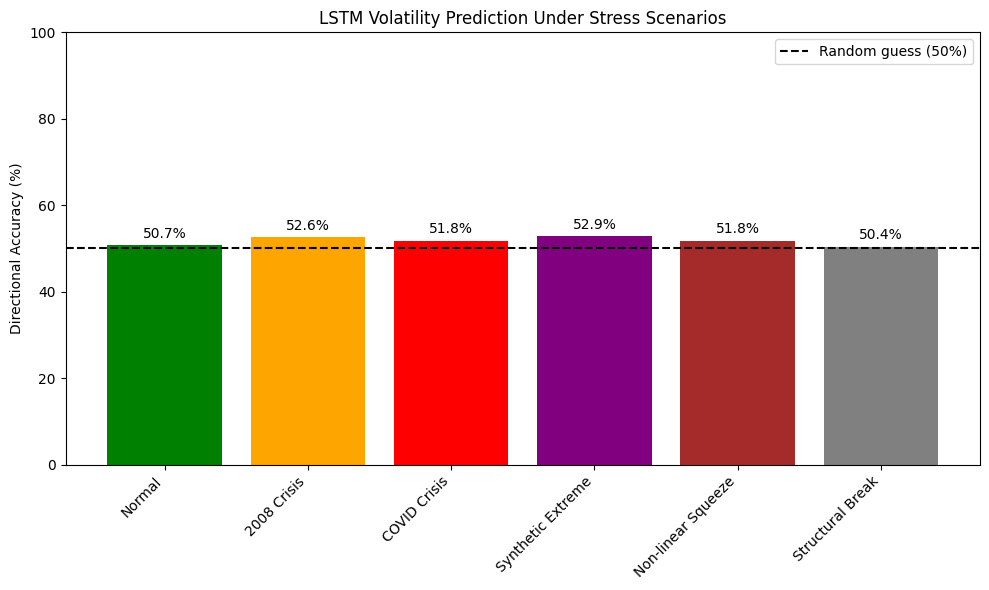


✅ LSTM VOLATILITY ANALYSIS COMPLETE


In [37]:
plt.figure(figsize=(10, 6))
scenarios = list(results.keys())
accuracies = list(results.values())

colors = ['green', 'orange', 'red', 'purple', 'brown', 'gray']
bars = plt.bar(scenarios, accuracies, color=colors[:len(scenarios)])
plt.axhline(y=50, color='black', linestyle='--', label='Random guess (50%)')
plt.ylabel('Directional Accuracy (%)')
plt.title('LSTM Volatility Prediction Under Stress Scenarios')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.legend()

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../results/lstm_volatility_results.png', dpi=150)
plt.show()

print("\n" + "="*70)
print("✅ LSTM VOLATILITY ANALYSIS COMPLETE")
print("="*70)